# Book Genre Multi Label Text Classification (text-based)
### Group Members: 
##### Kornel Zaleski X00222004 
##### Lukasz Kiraga X00227628 
##### Blessing Mayindu X00224444
##### Goal: The goal for this project is to predict the book genre based on its summary.

In [ ]:
# !pip install numpy
# !pip install matplotlib
# !pip install scikit-learn
# !pip install scikit-multilearn
# !pip install pandas
# !pip install torch torchvision torchaudio
# !pip install tensorflow
# !pip install transformers
# !pip install pandas 
# !pip install tabulate

## 1. Importing Necessary Libraries

In [28]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report, hamming_loss
import joblib
import pandas as pd
import tensorflow as tf
import torch

# https://pytorch.org/get-started/locally/
gpu_available = torch.cuda.is_available()
if gpu_available:
    print("CUDA Version:", torch.version.cuda)
    print("GPU Name:", torch.cuda.get_device_name(0))

import transformers
from transformers import BertTokenizer, BertModel, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, r2_score
import glob
import os


CUDA Version: 13.0
GPU Name: NVIDIA GeForce RTX 4060 Ti


## 2.  Data Exploration

### Analysing data through the three datasets

In [2]:
# BooksDataset.csv - df1
df1 = pd.read_csv('BooksDataset.csv')
print("BooksDataset.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df1.shape)
print("Columns: ", df1.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df1.describe(), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df1.info(), "\n")
print("\n" + ("-"*30), "\n")

# goodreads_data.csv - df2
df2 = pd.read_csv('goodreads_data.csv')
print("goodreads_data.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df2.shape)
print("Columns: ", df2.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df2.describe(include='all'), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df2.info(), "\n")
print("\n" + ("-"*30), "\n")

# google_books_dataset.csv - df3
df3 = pd.read_csv('google_books_dataset.csv')
print("google_books_dataset.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df3.shape)
print("Columns: ", df3.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df3.describe(), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df3.info())
print("\n" + ("-"*30), "\n")

# Number of nulls in not cleaned datasets
print("\nNull values in each uncleaned dataset\n")
print("Number of null values in BooksDataset.csv")
nulls_df1og = df1.isnull().sum()
print(nulls_df1og)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in goodreads_data.csv")
nulls_df2og = df2.isnull().sum()
print(nulls_df2og)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in google_books_dataset.csv")
nulls_df3og = df3.isnull().sum()
print(nulls_df3og)
print("\n" + ("-"*30), "\n")

# Display the first 15 rows of each not cleaned dataset for checking that cleaning worked as intended (checking if nan values are removed)
print("BooksDataset.csv\n\n", df1.head(15).to_markdown(index=False), "\n")
print("goodreads_data.csv\n\n", df2.head(15).to_markdown(index=False), "\n")
print("google_books_dataset.csv\n\n", df3.head(15).to_markdown(index=False), "\n")

BooksDataset.csv loaded successfully.

-----------Dataset Shape & Columns-----------

Shape:  (103082, 5)
Columns:  ['Title', 'Author', 'Description', 'Category', 'Publisher']

-----------Description of dataset columns-----------

                 Title  Author  \
count           103082  102990   
unique           97813   63579   
top     The Nutcracker      By   
freq                12    1043   

                                              Description  \
count                                               70213   
unique                                              68831   
top     For Ingest Only - Data needs to be cleaned up ...   
freq                                                   30   

                    Category         Publisher  
count                  76911            103074  
unique                  3106             13029  
top     "Fiction", "General"  Simon & Schuster  
freq                    2549              1521   


-----------Dataset Overall Info-----------



## 3. Data Cleaning
### Each dataset will be cleaned before merging

In [3]:
# Load and save the cleaned datasets

# BooksDataset.csv - df1
df1 = df1.dropna(subset=['Title', 'Description', 'Category'], how='any')
df1 = df1.drop_duplicates()
#df1.to_csv('BooksDatasetClean.csv', encoding="utf-8", index=False)

# goodreads_data.csv - df2
df2 = df2.dropna(subset=['Title', 'Description', 'Genres'], how='any')
df2 = df2.drop_duplicates()
#df2.to_csv('GoodreadsDatasetClean.csv', encoding="utf-8", index=False)

# google_books_dataset.csv - df3
df3 = df3.dropna(subset=['Title', 'Description', 'Category'], how='any')
df3 = df3.drop_duplicates()
#df3.to_csv('GoogleBooksDatasetClean.csv', encoding="utf-8", index=False)

# Number of nulls in cleaned datasets
print("\nNull values in each cleaned dataset\n")
print("Number of null values in BooksDatasetClean.csv")
nulls_df1 = df1.isnull().sum()
print(nulls_df1)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in GoodreadsDatasetClean.csv")
nulls_df2 = df2.isnull().sum()
print(nulls_df2)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in GoogleBooksDatasetClean.csv")
nulls_df3 = df3.isnull().sum()
print(nulls_df3)
print("\n" + ("-"*30), "\n")

# Nulls in each uncleaned and cleaned datasets comparison
print("\nNull values comparison (uncleaned vs cleaned)\n")
print("BooksDataset.csv vs BooksDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df1og, 'Cleaned': nulls_df1}), "\n")
print("\n" + ("-"*30), "\n")
print("goodreads_data.csv vs GoodreadsDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df2og, 'Cleaned': nulls_df2}), "\n")
print("\n" + ("-"*30), "\n")
print("google_books_dataset.csv vs GoogleBooksDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df3og, 'Cleaned': nulls_df3}), "\n")
print("\n" + ("-"*30), "\n")

# Display the first 15 rows of each cleaned dataset to ensure the cleaning process
print("BooksDatasetClean.csv\n\n", df1.head(15).to_markdown(index=False), "\n")
print("GoodreadsDatasetClean.csv\n\n", df2.head(15).to_markdown(index=False), "\n")
print("GoogleBooksDatasetClean.csv\n\n", df3.head(15).to_markdown(index=False), "\n")


Null values in each cleaned dataset

Number of null values in BooksDatasetClean.csv
Title           0
Author         11
Description     0
Category        0
Publisher       0
dtype: int64

------------------------------ 


Number of null values in GoodreadsDatasetClean.csv
Title          0
Author         0
Description    0
Genres         0
Avg Rating     0
Num Ratings    0
dtype: int64

------------------------------ 


Number of null values in GoogleBooksDatasetClean.csv
Title                 0
Subtitle           3565
Author              299
Publisher          1135
Description           0
Category              0
Search Category       0
dtype: int64

------------------------------ 


Null values comparison (uncleaned vs cleaned)

BooksDataset.csv vs BooksDatasetClean.csv
              Uncleaned  Cleaned
Title                0        0
Author              92       11
Description      32869        0
Category         26171        0
Publisher            8        0 


----------------------

## 4. Data merging


In [4]:

# Merging two csv files

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)

final_df = pd.concat(
    [df1[common_columns], df2[common_columns], df3[common_columns]],
    ignore_index=True
)

print(final_df.head())
# Here I am showing that the columns have difference headers . To fix this I need to make them the same and then put them together.
print("DF1 columns:")
print(df1.columns.tolist())

print("\nDF2 columns:")
print(df2.columns.tolist())

print("\nDF3 columns:")
print(df3.columns.tolist())

# Making all the columns lowercase
for df in [df1, df2, df3]:
    df.columns = df.columns.str.lower().str.strip()

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)
print(common_columns)

                                               Title  \
0                         Journey Through Heartsongs   
1                       In Search of Melancholy Baby   
2       The Dieter's Guide to Weight Loss During Sex   
3  Germs : Biological Weapons and America's Secre...   
4  The Good Book: Reading the Bible with Mind and...   

                                              Author  \
0                             Stepanek, Mattie J. T.   
1  Aksyonov, Vassily, Heim, Michael Henry, and Bo...   
2                                     Smith, Richard   
3  Miller, Judith, Engelberg, Stephen, and Broad,...   
4                                    Gomes, Peter J.   

                                         Description  
0  Collects poems written the eleven-year-old mus...  
1  The Russian author offers an affectionate chro...  
2  A humor classic, this tongue-in-cheek diet pla...  
3  Deadly germs sprayed in shopping malls, bomb-l...  
4  "The Bible and the social and moral consequenc..

In [5]:
#Here I am matching header names to the df3 
#pandas.DataFrame.rename

dfs = []
for df_loop in [df1, df2, df3]:
    df_loop.columns = df_loop.columns.str.lower().str.strip()
    dfs.append(df_loop)

df1,df2,df3 = dfs

df2 = df2.rename(columns={
    "book": "title",
    "author": "authors",
    "genres": "categories"
})

df1 = df1.rename(columns={
    "category": "categories",
    "author": "authors"
})
#df1 = df1.rename(columns={"categories": "category"})
#df2 = df2.rename(columns={"categories": "category"})
#df3 = df3.rename(columns={"categories": "category"})

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)

print("\nCommon columns:", common_columns)
# Merge
df = pd.concat([df1, df2, df3], ignore_index=True)
df.to_csv('MergedBooksDataset.csv', encoding="utf-8", index=False)

print("Number of null values in each column in the merged dataset:", df.isnull().sum())

print("\nFinal merged dataset:")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df.shape)
print("Columns: ", df.columns.tolist())
print("\n-----------Dataset First and Last 15 rows-----------\n")
print("First 15 rows\n\n", df.head(15).to_markdown(index=False), "\n")
print("Last 15 rows\n\n", df.tail(15).to_markdown(index=False), "\n")
print("\n-----------Description of dataset columns-----------\n")
print(df.describe(), "\n")
print("\n" + ("-"*30), "\n")
print("\nNumber of categories: ")
print(df["category"].value_counts().head(20))
print("\n-----------Dataset Overall Info-----------\n")
print(df.info())
print("Number of genres:", df["category"].value_counts().sum())



Common columns: Index(['title', 'description'], dtype='str')
Number of null values in each column in the merged dataset: title                  0
authors             7403
description            0
categories          7392
publisher          11039
avg rating         72618
num ratings        72618
subtitle           78695
author             75429
category           75130
search category    75130
dtype: int64

Final merged dataset:

-----------Dataset Shape & Columns-----------

Shape:  (82522, 11)
Columns:  ['title', 'authors', 'description', 'categories', 'publisher', 'avg rating', 'num ratings', 'subtitle', 'author', 'category', 'search category']

-----------Dataset First and Last 15 rows-----------

First 15 rows

 | title                                                                  | authors                                                                 | description                                                                                                                 

### Data Visualisation - Categories

##### Using a bar chart from matplotlib, it will show the top 10 categories that are most frequently occurring in the merged dataset

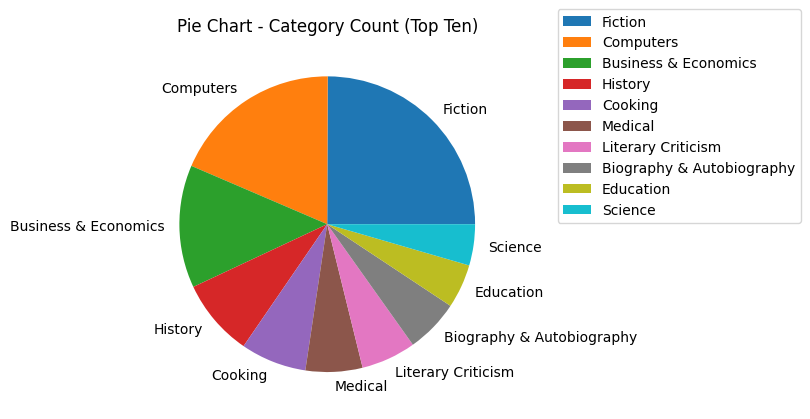

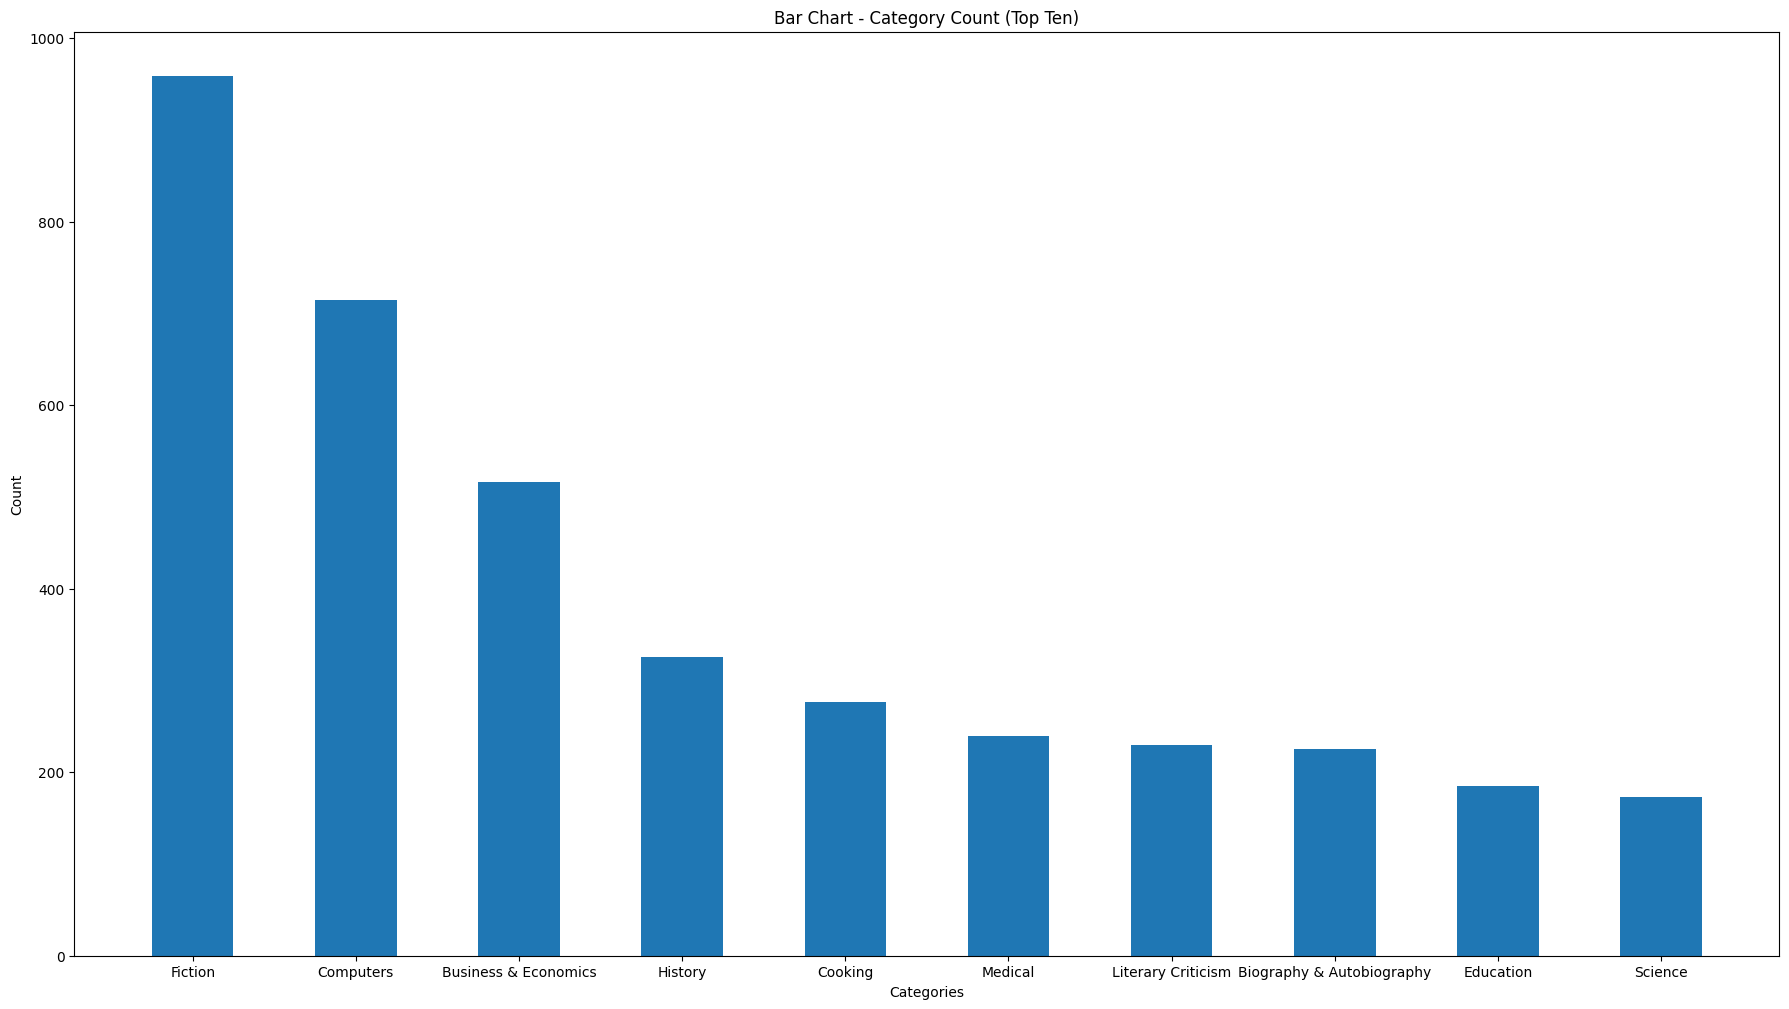

In [6]:
categories = df["category"].value_counts().head(10).index.tolist()
count = df["category"].value_counts().head(10).values.tolist()
new_categories = []

for category in categories:
    category = category.replace('"', '')
    new_categories.append(category)
    
categories = new_categories

plt.pie(count, labels=categories)
plt.title("Pie Chart - Category Count (Top Ten)")
plt.legend(categories, loc="upper right", bbox_to_anchor=(1.7, 1, 0.1, 0.1))
plt.show()

plt.figure(figsize=(22, 12))
plt.bar(categories, count, width=0.5)
plt.title("Bar Chart - Category Count (Top Ten)")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.show()

## 5. Feature Selection

In [7]:
#tfidf = TfidfVectorizer()
mlb = MultiLabelBinarizer()
#result = tfidf.fit_transform(df)
#print('\nidf values:') 
#for ele1, ele2 in zip(tfidf.get_feature_names_out(),
#tfidf.idf_): print(ele1, ':', ele2) 
#print('\nWord indexes:') 
#print(tfidf.vocabulary_)
#print('\ntf-idf value:') 
#print(result) 
#print('\ntf-idf values in matrix form:') 
#print(result.toarray())
#the max feature will keep the 5000 most usefull words.
df = df.dropna(subset=['categories'], how='any')
tfidf = TfidfVectorizer(max_features=5000 ,stop_words='english')
# the stop word will remove useless word like 'a','is' etc -They are jsut filler words.
texts = (df['title'] + " " + df['description'])
X = texts
print(df['categories'].head(10))
categories_list = df['categories'].apply(lambda x: [category.strip().replace('"', '') for category in str(x).split(',')] if pd.notna(x) else []).tolist()
#categories_list = df['categories'].apply(lambda x: [x] if isinstance(x, str) else x)
y = mlb.fit_transform(categories_list)

print("feature matrix shape:", X.shape)
print("Number of genres:",len(mlb.classes_))
print("genre:", mlb.classes_)

0                                "Poetry", "General"
1             "Biography & Autobiography", "General"
2    "Health & Fitness", "Diet & Nutrition", "Diets"
3     "Technology & Engineering", "Military Science"
4        "Religion", "Biblical Biography", "General"
5    "Biography & Autobiography", "Personal Memoirs"
6                     "Political Science", "General"
7                          "Pets", "Cats", "General"
8                     "Political Science", "General"
9                               "Fiction", "General"
Name: categories, dtype: str
feature matrix shape: (75130,)
Number of genres: 2423
genre: ['12th Century' '15th Century' '16th Century' ... 'etc.' 'etc.)'
 'the Gospels & Acts']


## 6. Dataset Splits

#### We split the dataset into three sets:
 - **Training set**: fitting the models (70%)
 - **Validation set**: tuning and comparison (15%)
 - **Test set**: final unbiased evaluation (15%)

In [8]:
# Splitting the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Checking the shapes of the training, validation, and test sets
print("Training set shape: ", X_train.shape)
print("Validation set shape: ", X_val.shape)
print("Test set shape: ", X_test.shape)

# Checking the first 5 rows of training genres and the number of genres
print(mlb.inverse_transform(y_train[:5]))
print(len(mlb.classes_))

Training set shape:  (52591,)
Validation set shape:  (11269,)
Test set shape:  (11270,)
[('Fiction', 'General', 'Mystery & Detective'), ('Business & Economics', 'General', 'Investments & Securities'), ('American', 'Cooking', 'Regional & Ethnic', 'Southern States'), ('Juvenile Fiction', 'Media Tie-In'), ('Boating', 'Sports & Recreation')]
2423


## TF-IDF Vectorizer
#### We covert training, validation and test set texts into TF-IDF vectors so the ML models work 

In [9]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

## Machine Learning Models
### 1. Logistic Regression

In [10]:
# Initialise the Logistic Regression model with the maximum number of iterations as the parameter
# We use OneVsRestClassifier wrapper for multi-label classification
log_reg = OneVsRestClassifier(LogisticRegression(max_iter=100, solver='liblinear'))

# Fit the Logistic Regression model on the training data
log_reg.fit(X_train_tfidf, y_train)

# Make predictions on the validation and test sets
y_val_lr = log_reg.predict(X_val_tfidf)
y_test_lr = log_reg.predict(X_test_tfidf)

# Calculate accuracy classification scores
val_acc_lr = classification_report(y_val, y_val_lr, target_names=mlb.classes_)
test_acc_lr = classification_report(y_test, y_test_lr, target_names=mlb.classes_)

# Prints the validation and test accuracy of the Logistic Regression model
print("Validation Classification Report:\n", val_acc_lr, "\nTest Classification Report:\n", test_acc_lr)

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 14 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 29 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 63 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 67 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 102 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 103 is present in all training examples.
  warni

Validation Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
                                             15th Century       0.00      0.00      0.00         1
                                             16th Century       0.00      0.00      0.00         1
                                             17th Century       0.00      0.00      0.00         1
                                             18th Century       0.00      0.00      0.00         1
                                             19th Century       0.00      0.00      0.00        35
                                             20th Century       0.00      0.00      0.00        43
                                             21st Century       0.00      0.00      0.00        11
                                                       A+       0.00     

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

### 2. Naive Bayes

In [11]:
# Initialize the Naive Bayes model with the OneVsRestClassifier wrapper for multi-label classification
naive_bayes = OneVsRestClassifier(MultinomialNB())

# Fit the Naive Bayes model on the training data
naive_bayes.fit(X_train_tfidf, y_train)

# Make predictions on the validation and test sets
y_val_nb = naive_bayes.predict(X_val_tfidf)
y_test_nb = naive_bayes.predict(X_test_tfidf)

# Calculate accuracy classification scores
val_acc_nb = classification_report(y_val, y_val_nb, target_names=mlb.classes_)
test_acc_nb = classification_report(y_test, y_test_nb, target_names=mlb.classes_)

# Prints the validation and test accuracy of the Naive Bayes model
print("Validation Classification Report:\n", val_acc_nb, "\nTest Classification Report:\n", test_acc_nb)

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 14 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 29 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 63 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 67 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 102 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 103 is present in all training examples.
  warni

Validation Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
                                             15th Century       0.00      0.00      0.00         1
                                             16th Century       0.00      0.00      0.00         1
                                             17th Century       0.00      0.00      0.00         1
                                             18th Century       0.00      0.00      0.00         1
                                             19th Century       0.00      0.00      0.00        35
                                             20th Century       0.00      0.00      0.00        43
                                             21st Century       0.00      0.00      0.00        11
                                                       A+       0.00     

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

## Deep Learning Model

### 3. BERT (Bidirectional Encoder Representations from Transformers)
##### We now do the BERT tokenizer so we firstly take the tokenizer from huggingface, then we initialise the tokenizer for the two sets with the function and then tokenize them.

In [13]:
# BERT Tokenizer
# Initialising the tokenizer from the hugging face transformers library for the BERT model.
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

# Function to tokenize the data using the tokenizer
def tokenize_data(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors='pt')

# Tokenizing the training, validation, and test data using the tokenize_data function
X_train_tokenize = tokenize_data(X_train)
X_valid_tokenize = tokenize_data(X_val)


### BERT - Model Preparation and Fitting

In [29]:
# X_train_tokens = tokenizer.convert_ids_to_tokens(X_train_tokenize['input_ids'][0])
# print(X_train_tokens)
# X_valid_tokens = tokenizer.convert_ids_to_tokens(X_valid_tokenize['input_ids'][0])
# print(X_valid_tokens)

# Converting tokenized data to lists
train_encodings = {key: val.tolist() for key, val in X_train_tokenize.items()}
valid_encodings = {key: val.tolist() for key, val in X_valid_tokenize.items()}

# Custom dataset class for multi-label classification to prepare BERT
class MultiLabelBookGenreDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item
    
# Creating datasets for training and validation using the class above with the encodings and label splits
train_dataset = MultiLabelBookGenreDataset(train_encodings, y_train)
valid_dataset = MultiLabelBookGenreDataset(valid_encodings, y_val)

# Initialise BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(mlb.classes_),
    problem_type='multi_label_classification'
)

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
# criterion = torch.nn.BCEWithLogitsLoss()

# If NVIDIA GPU is available it moves the model to the GPU otherwise defaults to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print("BERT successfully set up")
if device:
    print("Moved to device NVIDIA GPU CUDA -", torch.cuda.get_device_name(0))
else:
    print("Moved to device CPU by default")

# Setting up the training arguments for the Trainer class from transformers
train_arguments = TrainingArguments(
    output_dir='./BERTresults',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    fp16=gpu_available,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_dir='./logs'
)

# Create the trainer to train BERT
trainer = Trainer(model=model, args=train_arguments, train_dataset=train_dataset, eval_dataset=valid_dataset)

# Starts training BERT
trainer.train()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT successfully set up
Moved to device NVIDIA GPU CUDA - NVIDIA GeForce RTX 4060 Ti


Epoch,Training Loss,Validation Loss
1,0.006400,0.006437
2,0.005500,0.005466
3,0.005000,0.005051


TrainOutput(global_step=19722, training_loss=0.0077364271618678955, metrics={'train_runtime': 2859.9506, 'train_samples_per_second': 55.166, 'train_steps_per_second': 6.896, 'total_flos': 4.241417054044262e+16, 'train_loss': 0.0077364271618678955, 'epoch': 3.0})